# Example 3 - Notebook

In [ ]:
import os
from pathlib import Path

# force the base dir to the current working directory
BASE_DIR = Path.cwd().resolve()
os.environ['TSLIES_DIR'] = str(BASE_DIR)

Date folder: 2026-03-04
Time folder: 1716


/home/andrea-adelfio/anaconda3/envs/rootenv/lib/python3.11/site-packages/tslies/config.py:157: RuntimeWarning: TSLies base directory is not configured. Outputs will be stored under ~/.tslies.
  return _resolve_and_cache(


PosixPath('/home/andrea-adelfio/VSCode/Workspace INFN/TSLies/tslies/examples/example3')

In [2]:
from tslies.background.bnnpredictor import BNNPredictor
from tslies.trigger import Trigger
from tslies.utils import Data, File
from tslies.plotter import Plotter

try:
    from example_config import y_cols, y_pred_cols, x_cols, x_cols_excluded, units, latex_y_cols, thresholds
    from catalogs import CatalogsReader
except ModuleNotFoundError:
    from tslies.examples.example3.example_config import (
        y_cols,
        y_pred_cols,
        x_cols,
        x_cols_excluded,
        units,
        latex_y_cols,
        thresholds,
    )
    from tslies.examples.example3.catalogs import CatalogsReader


2026-03-04 17:14:50.191236: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 17:14:50.200418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772640890.210360  745014 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772640890.213160  745014 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-04 17:14:50.223809: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Date folder: 2026-03-04
Time folder: 1714


/home/andrea-adelfio/anaconda3/envs/rootenv/lib/python3.11/site-packages/tslies/config.py:157: RuntimeWarning: TSLies base directory is not configured. Outputs will be stored under ~/.tslies.
  return _resolve_and_cache(


In [9]:
catalog = CatalogsReader().catalog_df
print(catalog.head())

         NAME TRIGGER_TYPE                    TIME            TRIGGER_TIME  \
0  GRB240101A          GRB 2024-01-01 14:19:57.331 2024-01-01 14:20:17.331   
1  GRB240101B          GRB 2024-01-01 20:25:19.378 2024-01-01 20:25:39.378   
2  GRB240102A          GRB 2024-01-02 17:34:35.340 2024-01-02 17:34:55.340   
3  GRB240109A          GRB 2024-01-09 04:01:15.126 2024-01-09 04:01:35.126   
4  GRB240112C          GRB 2024-01-12 17:37:04.977 2024-01-12 17:37:24.977   

                 END_TIME CAT_NAME  
0 2024-01-01 14:20:33.747    SWIFT  
1 2024-01-01 20:27:53.394    SWIFT  
2 2024-01-02 17:36:49.644    SWIFT  
3 2024-01-09 04:01:35.206    SWIFT  
4 2024-01-12 17:37:29.901    SWIFT  


Reading dfs from files: 100%|██████████| 1/1 [00:00<00:00,  2.10it/s]


    top_low  top_middle  top_high  Xpos_low  Xpos_middle  Xpos_high  Xneg_low  \
0  0.000523    0.006117  0.006828  0.000395     0.008757   0.007738  0.000387   
1  0.000494    0.007300  0.006395  0.000592     0.009213   0.007583  0.000809   
2  0.000207    0.006305  0.005059  0.000748     0.006452   0.009200  0.000522   
3  0.000737    0.005195  0.004287  0.000615     0.006670   0.006769  0.000644   
4  0.000265    0.006271  0.005563  0.000499     0.007446   0.007624  0.000671   

   Xneg_middle  Xneg_high  Ypos_low  ...  SC_VELOCITY_0  SC_VELOCITY_1  \
0     0.009605   0.007754  0.000447  ...   -6846.322754     -20.029079   
1     0.009740   0.008607  0.000516  ...   -6846.312012     -27.842203   
2     0.007232   0.006714  0.000756  ...   -6846.292480     -36.221500   
3     0.006117   0.006266  0.001161  ...   -6846.264648     -44.598328   
4     0.009995   0.008697  0.000576  ...   -6846.229004     -52.977978   

   SC_VELOCITY_2  SAA_EXIT  TIME_FROM_SAA  SUN_IS_EARTH_OCCULTED  \


Plotting tiles: 6it [00:00, 91.96it/s]


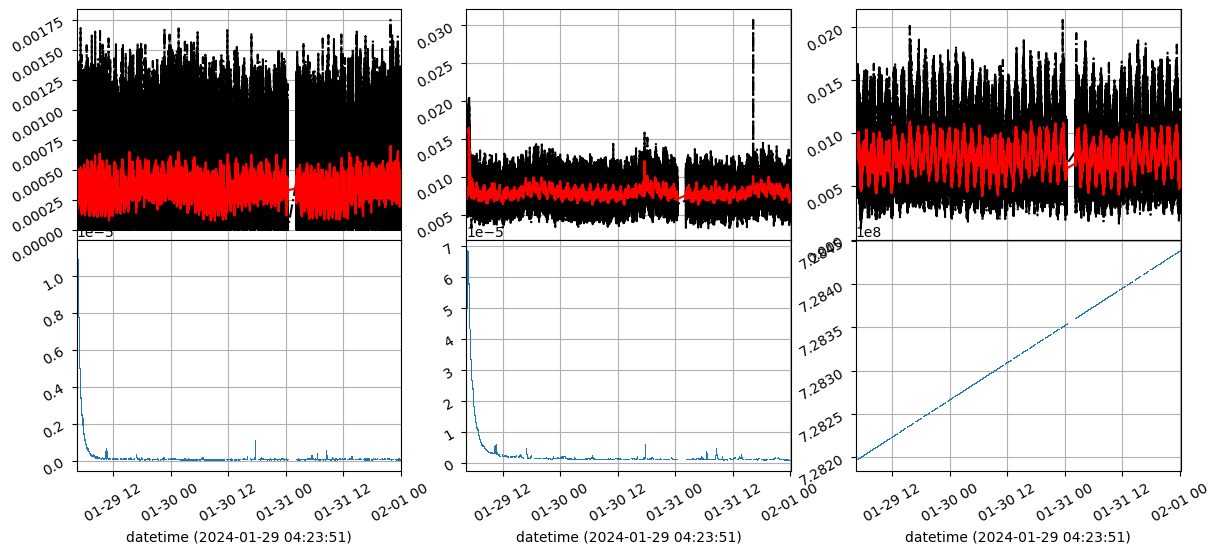

In [10]:
x_cols = [col for col in x_cols if col not in x_cols_excluded]
inputs_outputs_df = File().read_dfs_from_weekly_pk_folder(start=0, stop=1000)
print(inputs_outputs_df.head())
# inputs_outputs_df = Data.get_masked_dataframe(data=inputs_outputs_df, start=0, stop=2000, column='index')
Plotter(df = inputs_outputs_df[[col for col in y_cols if 'Xpos' in col] + [f'{col}_smooth' for col in y_cols if 'Xpos' in col] + ['GOES_XRSA_HARD', 'GOES_XRSB_SOFT', 'MET', 'datetime']], label = 'Inputs and outputs').df_plot_tiles(x_col = 'datetime', excluded_cols = [], y_cols=y_cols, latex_y_cols=latex_y_cols, show = True, smoothing_key='smooth')


In [11]:
"""Runs the neural network model."""
nn = BNNPredictor(inputs_outputs_df, y_cols, x_cols, y_pred_cols, latex_y_cols, units, False)
hyperparams_combinations = {
    "units_for_layers": ([90], [90], [90], [70], [50]),
    "epochs": [6],
    "bs": [1000],
    "do": [0.02],
    "norm": [0],
    "drop": [0],
    "opt_name": ["Adam"],
    "lr": [0.001],
    "metrics": ["negative_log_likelihood_var+mae_bnn+spectral_loss_bnn"],
    "loss_type": ["negative_log_likelihood_var+mae_bnn+spectral_loss_bnn"],
}

for params in nn.get_hyperparams_combinations(hyperparams_combinations, use_previous=False):
    nn.set_hyperparams(params)
    nn.create_model()
    nn.train()
    nn.update_summary()
    Plotter.save(params)


BNNPredictor - 1714
x_cols: ['SC_POSITION_0', 'SC_POSITION_1', 'SC_POSITION_2', 'LAT_GEO', 'LON_GEO', 'RAD_GEO', 'RA_ZENITH', 'DEC_ZENITH', 'B_MCILWAIN', 'L_MCILWAIN', 'GEOMAG_LAT', 'LAMBDA', 'RA_SCZ', 'START', 'LAT_MODE', 'LAT_CONFIG', 'DATA_QUAL', 'DEC_SCZ', 'RA_SCX', 'DEC_SCX', 'RA_NPOLE', 'DEC_NPOLE', 'ROCK_ANGLE', 'QSJ_1', 'QSJ_2', 'QSJ_3', 'QSJ_4', 'RA_SUN', 'DEC_SUN', 'SC_VELOCITY_0', 'SC_VELOCITY_1', 'SC_VELOCITY_2', 'GOES_XRSA_HARD', 'GOES_XRSB_SOFT', 'TIME_FROM_SAA', 'SAA_EXIT']
y_cols: ['top_low', 'top_middle', 'top_high', 'Xpos_low', 'Xpos_middle', 'Xpos_high', 'Xneg_low', 'Xneg_middle', 'Xneg_high', 'Ypos_low', 'Ypos_middle', 'Ypos_high', 'Yneg_low', 'Yneg_middle', 'Yneg_high']
Epoch 1/6
106/106 [==============================] - 1s 6ms/step - loss: 18.3391 - negative_log_likelihood_var: 0.4574 - mae_bnn: 0.7638 - spectral_loss_bnn: 17.1164 - val_loss: 17.7420 - val_negative_log_likelihood_var: 0.4285 - val_mae_bnn: 0.7507 - val_spectral_loss_bnn: 16.5619
Epoch 2/6
106/106

In [ ]:
y_pred = None
if y_pred is None or len(y_pred) == 0:
    batch_size = len(inputs_outputs_df)
    for i in range(0, len(inputs_outputs_df), batch_size):
        _, y_pred = nn.predict(
            start=i,
            end=i + batch_size,
            write_bkg=True,
            num_batches=1,
            save_predictions_plot=False,
        )

tiles_df = Data.merge_dfs(inputs_outputs_df, y_pred)

for face, face_pred in zip(y_cols, y_pred_cols):
    tiles_df[f"{face}_norm"] = (tiles_df[face] - tiles_df[face_pred]) / tiles_df[f"{face}_std"]

reset = tiles_df["MET"].diff() > 60
trigger = Trigger(
    tiles_df,
    y_cols,
    y_pred_cols,
    thresholds=thresholds,
    trigger_type="focus",
    units=units,
    latex_y_cols=latex_y_cols,
)
trigger.run(reset_condition=reset)
merged_anomalies, return_df = trigger.identify_and_merge_triggers(merge_interval=60)
detections_df = trigger.get_detections_df(["MET"])
print(detections_df)
trigger.save_detections_csv(detections_df=detections_df)
detections_df, filtered_anomalies = trigger.filter_from_catalog(catalog, merged_anomalies, detections_df)
print(detections_df)
trigger.save_detections_csv(detections_df=detections_df, suffix="_in_catalog")
trigger.plot_anomalies(
    filtered_anomalies,
    return_df,
    support_vars=["GOES_XRSA_HARD_EARTH_OCCULTED"],
)


6303/6303 [==============================] - 3s 457us/step


In [ ]:
import pandas as pd

tiles_df = inputs_outputs_df.copy()
stats = []
for face in y_cols:
    tiles_df[f"{face}_std"] = tiles_df[face].rolling(window=120, center=True, min_periods=1).std()
    tiles_df[f"{face}_pred"] = tiles_df[face].rolling(window=120, center=True, min_periods=1).mean()

    norm_face = (tiles_df[face] - tiles_df[f"{face}_pred"]) / tiles_df[f"{face}_std"]
    stats.append(
        {
            "face": face,
            "std": round(norm_face.std(), 3),
            "mean": round(norm_face.mean(), 3),
        }
    )

stats_df = pd.DataFrame(stats)
print(stats_df.set_index("face").T.to_string(header=True))

reset = tiles_df["MET"].diff() > 60
trigger = Trigger(
    tiles_df,
    y_cols,
    y_pred_cols,
    thresholds=thresholds,
    trigger_type="focus",
    units=units,
    latex_y_cols=latex_y_cols,
)
trigger.run(reset_condition=reset)
merged_anomalies, return_df = trigger.identify_and_merge_triggers(merge_interval=60)
detections_df = trigger.get_detections_df(["MET"])
trigger.save_detections_csv(detections_df=detections_df)

detections_df, filtered_anomalies = trigger.filter_from_catalog(catalog, merged_anomalies, detections_df)
trigger.save_detections_csv(detections_df=detections_df, suffix="_in_catalog")
for x, v in filtered_anomalies.items():
    merged_anomalies[x] = v
trigger.plot_anomalies(filtered_anomalies, return_df, support_vars=["GOES_XRSA_HARD_EARTH_OCCULTED"])


face  top_low  top_middle  top_high  Xpos_low  Xpos_middle  Xpos_high  Xneg_low  Xneg_middle  Xneg_high  Ypos_low  Ypos_middle  Ypos_high  Yneg_low  Yneg_middle  Yneg_high
std     0.995       0.995     0.995     0.996        0.995      0.994     0.995        0.995      0.995     0.995        0.995      0.994     0.996        0.995      0.994
mean   -0.000      -0.000     0.000    -0.000       -0.000     -0.000    -0.000       -0.000     -0.000    -0.000       -0.000     -0.000    -0.000       -0.000     -0.000


Identifying triggers: 100%|██████████| 2044/2044 [00:00<00:00, 240859.62it/s]


Merging 2159 triggers... 1204 anomalies in total.


Plotting anomalies: 100%|██████████| 2/2 [00:07<00:00,  3.85s/it]
